In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Housing.csv")
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [ ]:
#Null values
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [ ]:
#Duplicate value
df.duplicated().sum()

np.int64(0)

In [ ]:
#Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["mainroad"] = le.fit_transform(df["mainroad"])
df["guestroom"] = le.fit_transform(df["guestroom"])
df["basement"] = le.fit_transform(df["basement"])
df["hotwaterheating"] = le.fit_transform(df["hotwaterheating"])
df["airconditioning"] = le.fit_transform(df["airconditioning"])
df["prefarea"] = le.fit_transform(df["prefarea"])
df["furnishingstatus"] = le.fit_transform(df["furnishingstatus"])



In [ ]:
# feature selection
x = df.drop("price", axis=1)
y = df["price"]

In [ ]:
#Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
print(x_scaled)

[[ 1.04672629  1.40341936  1.42181174 ...  1.51769249  1.80494113
  -1.40628573]
 [ 1.75700953  1.40341936  5.40580863 ...  2.67940935 -0.55403469
  -1.40628573]
 [ 2.21823241  0.04727831  1.42181174 ...  1.51769249  1.80494113
  -0.09166185]
 ...
 [-0.70592066 -1.30886273 -0.57018671 ... -0.80574124 -0.55403469
   1.22296203]
 [-1.03338891  0.04727831 -0.57018671 ... -0.80574124 -0.55403469
  -1.40628573]
 [-0.5998394   0.04727831 -0.57018671 ... -0.80574124 -0.55403469
   1.22296203]]


In [12]:
#Splitting the dataset
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_scaled,y,test_size = 0.2, random_state = 42)


In [13]:
# Model Building
from sklearn.linear_model import LinearRegression
model =LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
print(model.intercept_)
print(model.coef_)

4738612.162870701
[ 511355.31486431   57939.76418471  550762.10873532  352072.08634443
  127770.25363585   89178.0079421   187581.88438844  143909.24149324
  365086.93393877  194330.06533066  267023.36435044 -160043.58443798]


In [ ]:
#Prediction
y_predict = model.predict(x_test)
print(y_predict)

[5203691.70963177 7257004.02115475 3062828.59668172 4559591.65374424
 3332932.30559783 3563080.67918996 5645466.3121997  6413979.66873635
 2755831.54819001 2668938.6607523  9570600.29915351 2827431.50860062
 3195686.25834091 3352263.99438472 3713879.49996132 5301088.2443575
 2987920.26669681 4810799.8212371  4383031.70489929 3525092.18938646
 5796259.50068013 5840000.702993   2760214.60864101 4762590.14920608
 5204755.73895204 7515542.71619022 3254681.68956383 5236164.45964445
 8178523.1682028  3434166.1567565  6443921.58767582 3346004.77919185
 6742324.74004132 4154936.84088665 3589152.47491253 5788125.92515323
 4768370.18154077 4391684.04193173 3217657.04549936 4638196.61928879
 4522160.27786713 3541284.06127246 7238136.1194117  4021515.68926614
 3701978.76822756 4298879.55563098 6705004.0206061  3993466.52296897
 3798185.05328058 3451821.56242891 7293996.8686746  2832905.26972679
 4378698.14769929 4468002.85418353 3714623.89765884 2718466.9028278
 7524449.64983625 2950437.14952811 4

In [ ]:
#Evaluation
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_predict)
mse = mean_squared_error(y_test, y_predict)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_predict)

print("\nModel Evaluation Metrics:")

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)


Model Evaluation Metrics:
Mean Absolute Error (MAE): 979679.6912959907
Mean Squared Error (MSE): 1771751116594.04
Root Mean Squared Error (RMSE): 1331071.4167895124
R2 Score: 0.6494754192267793


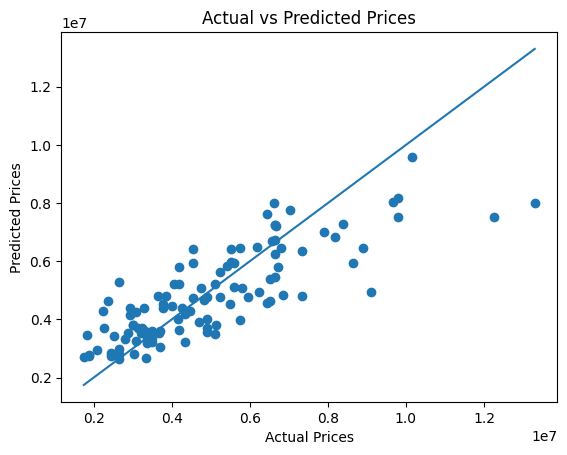

In [17]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(y_test, y_predict)

# Perfect prediction line
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)])

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()